In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# import data from google drive
penguins_data = pd.read_csv('/content/drive/MyDrive/ML datasets/penguins.csv')

# removing rows with missing walues
penguins_data = penguins_data.dropna()

In [3]:
# defining target and feature variables
x = penguins_data.drop('species', axis = 1)
y = penguins_data['species']

# encoding categorical variables
x = pd.get_dummies(x, drop_first = True)

In [4]:
# training and testing set splitting
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 524)

In [5]:
# decision tree model with hyperparameter tuning

# parameter distribution
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, "sqrt", "log2"]
}

# grid search cv
grid_search = GridSearchCV(
    estimator = DecisionTreeClassifier(random_state = 524),
    param_grid = param_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)

# fitting the data into the grid search
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=524),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15, 20],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [6]:
# finding the best model
best_dt = grid_search.best_estimator_

In [7]:
# model evaluation

# predicting with the best model
y_pred = best_dt.predict(x_test)

print('accuracy:', round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred))



accuracy: 0.97
              precision    recall  f1-score   support

      Adelie       0.92      1.00      0.96        24
   Chinstrap       1.00      0.87      0.93        15
      Gentoo       1.00      1.00      1.00        28

    accuracy                           0.97        67
   macro avg       0.97      0.96      0.96        67
weighted avg       0.97      0.97      0.97        67



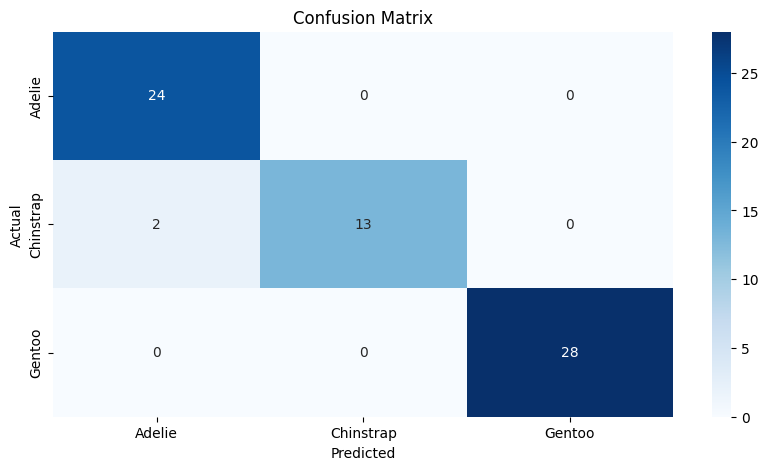

In [8]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 5))
sns.heatmap(
    cm,
    annot = True,
    fmt = "d",
    cmap = "Blues",
    xticklabels = best_dt.classes_,
    yticklabels = best_dt.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

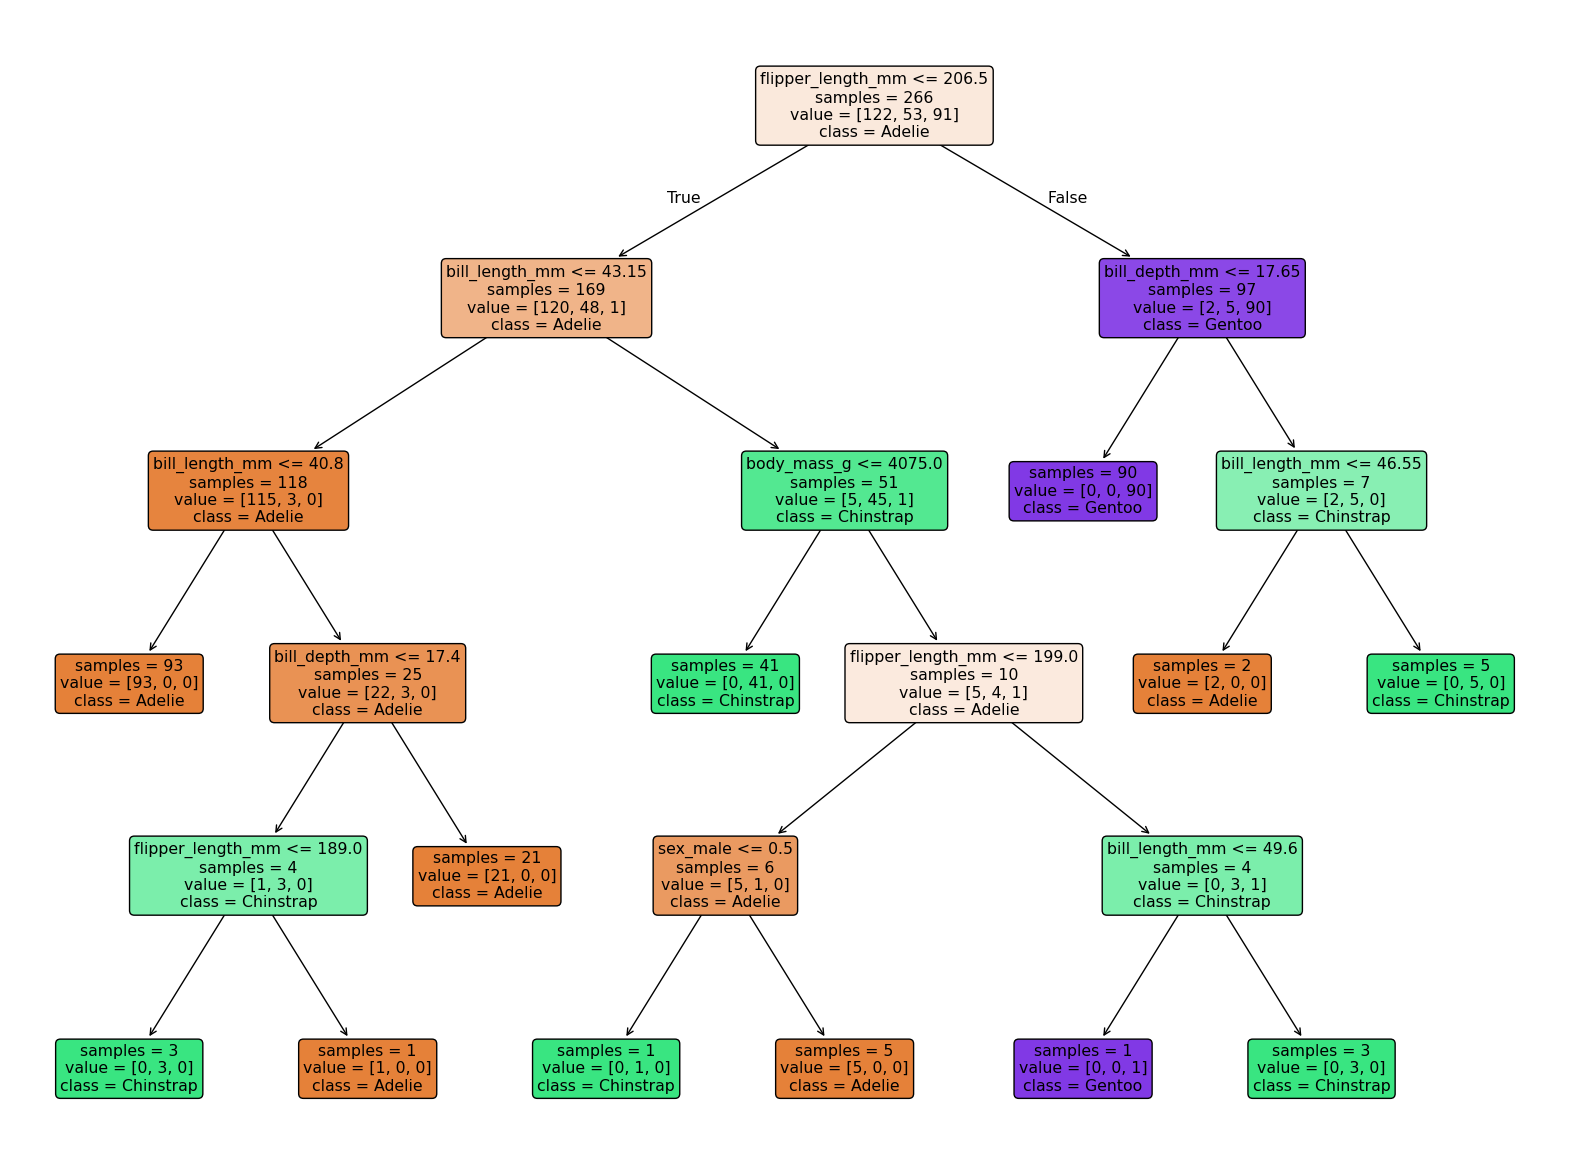

In [9]:
# visualizing decision tree

plt.figure(figsize=(20, 15))
plot_tree(
    best_dt,
    feature_names = x.columns,
    class_names = best_dt.classes_,
    filled = True,
    rounded = True,
    impurity = False
)
plt.show()

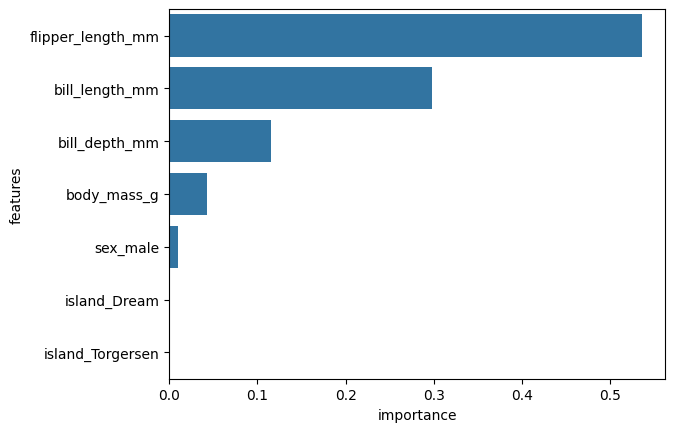

In [10]:
# feature importance plot

feature_importances = pd.DataFrame(best_dt.feature_importances_, index = x.columns, columns = ['importance']).sort_values('importance', ascending = False)
sns.barplot(data = feature_importances, x = 'importance', y = feature_importances.index)
plt.ylabel('features')
plt.show()

The model relies primarily on morphological features like flipper length, bill length, and bill depth to classify penguin species, while sex and island have minimal to no impact.